# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y)).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Helen Ayalew

**Date:** 09/07/2026

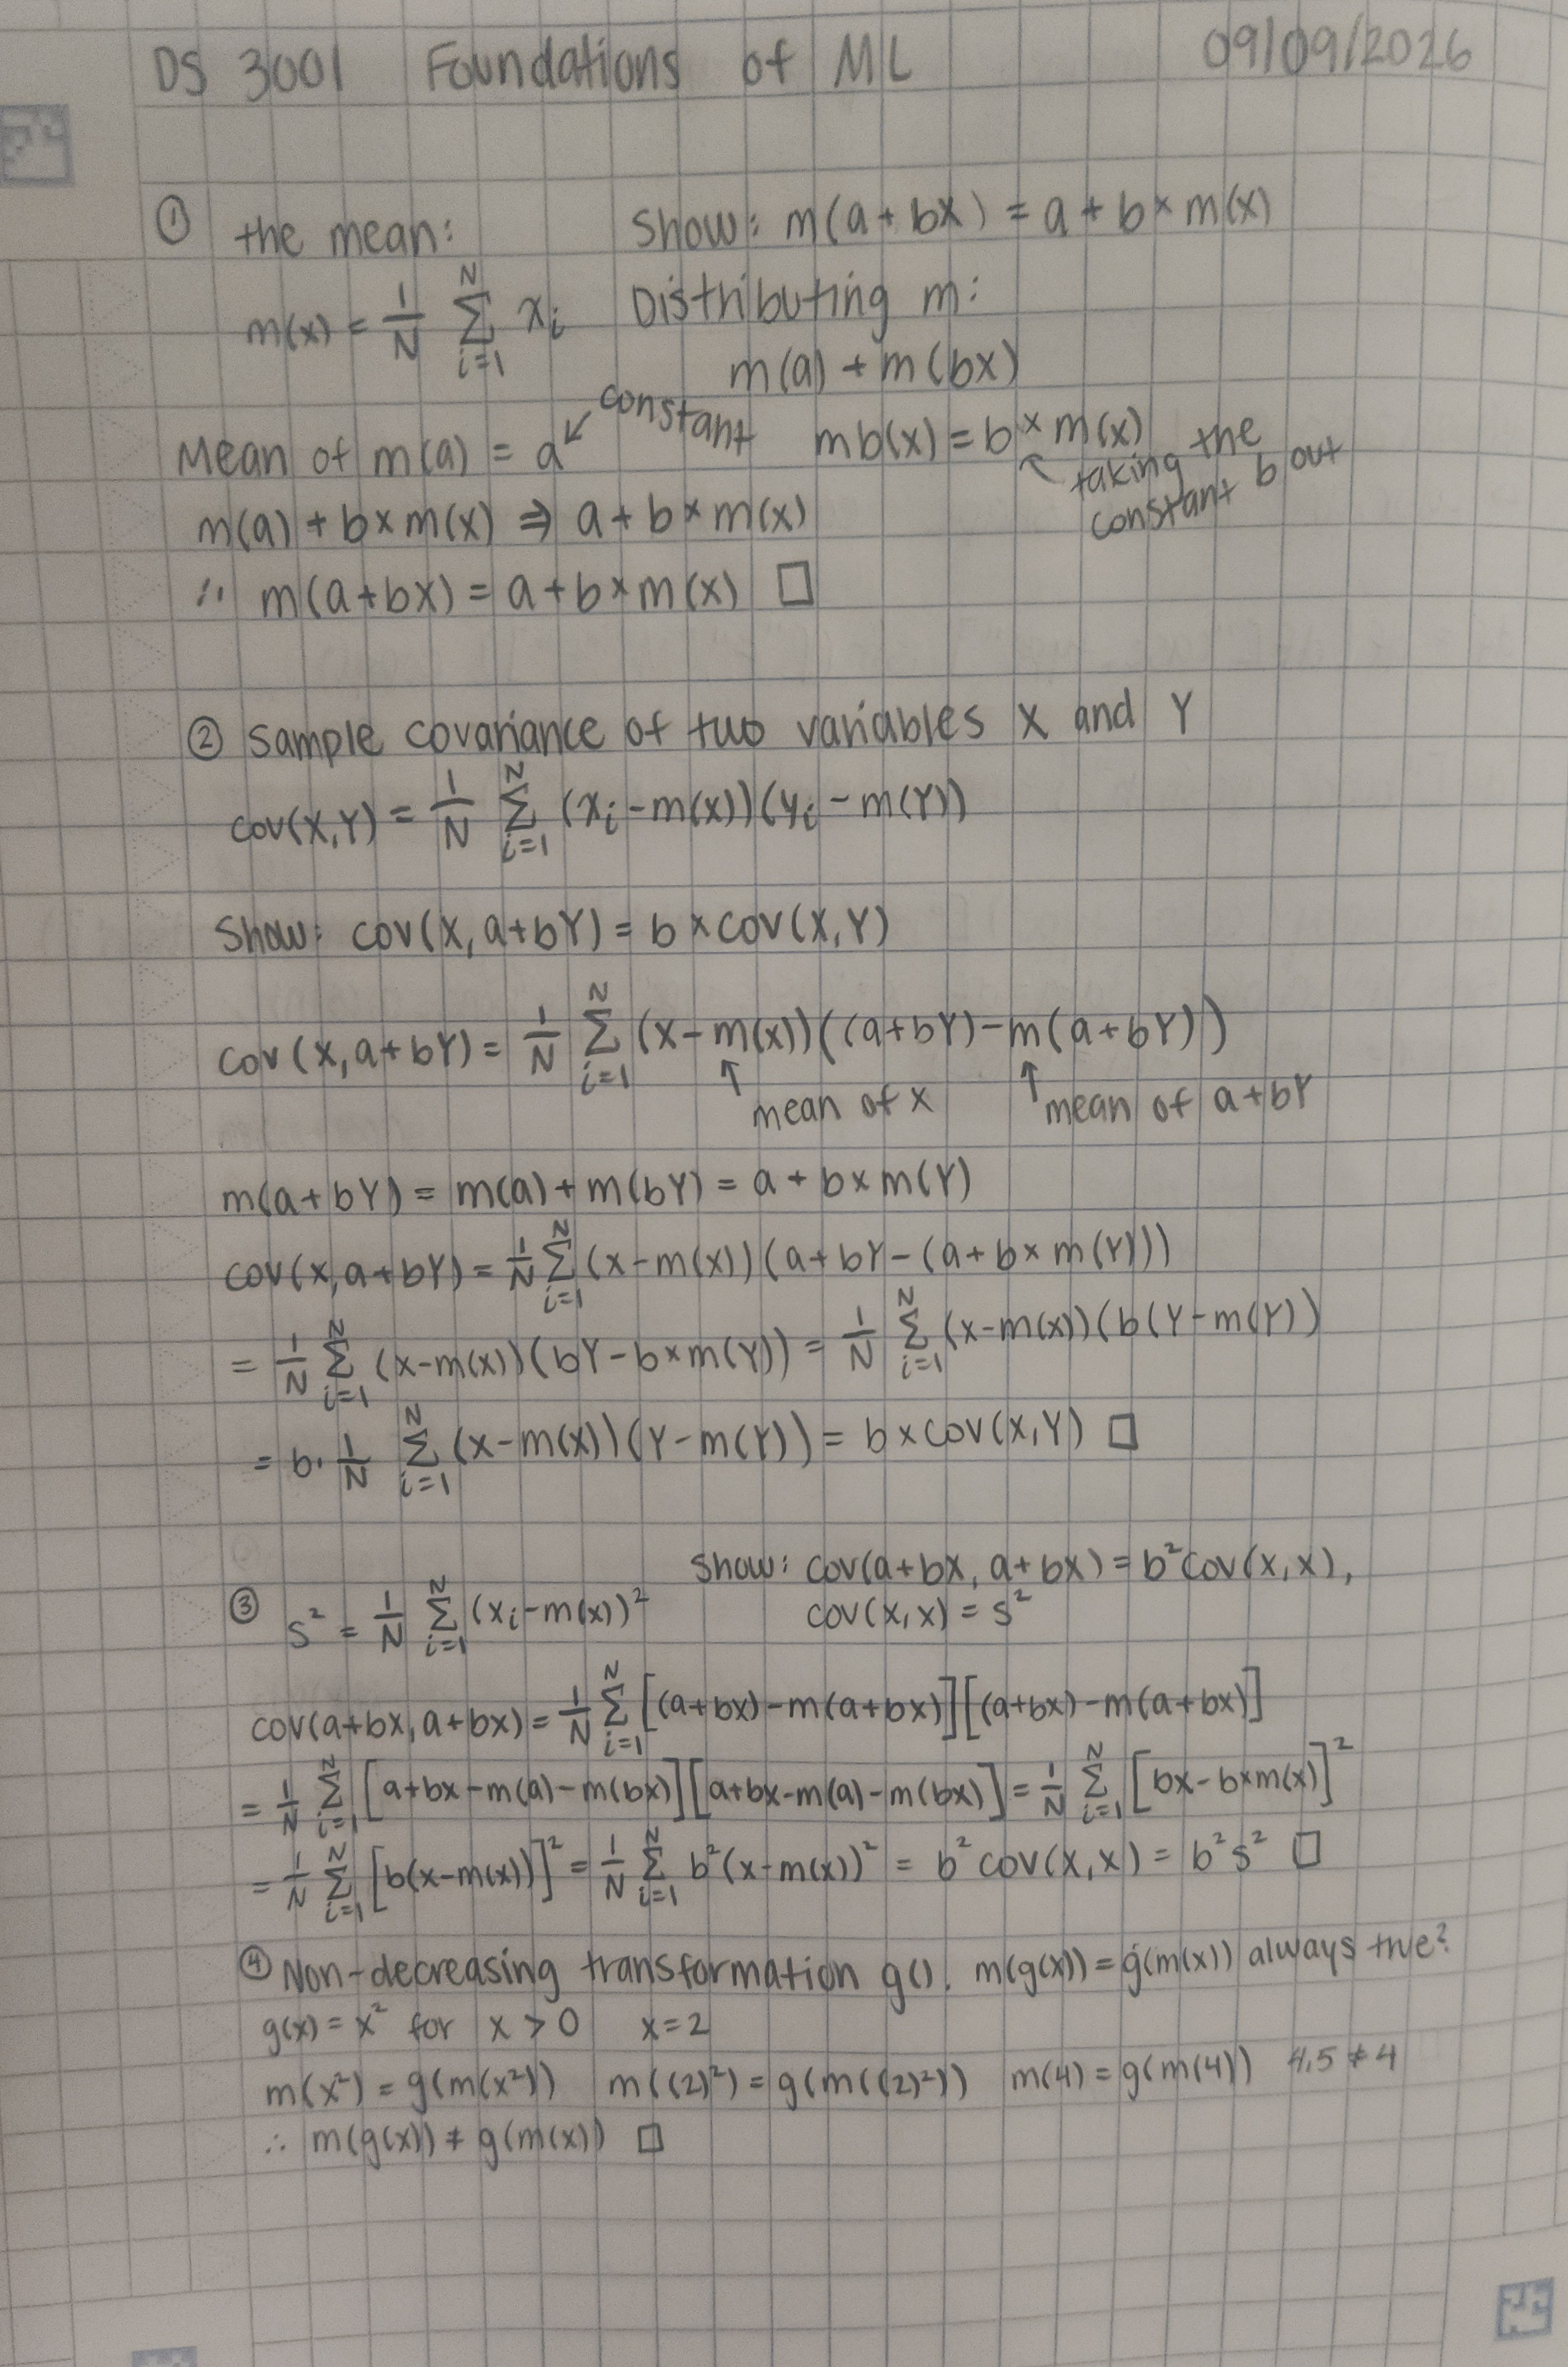

Text(0, 0.5, 'Amount')

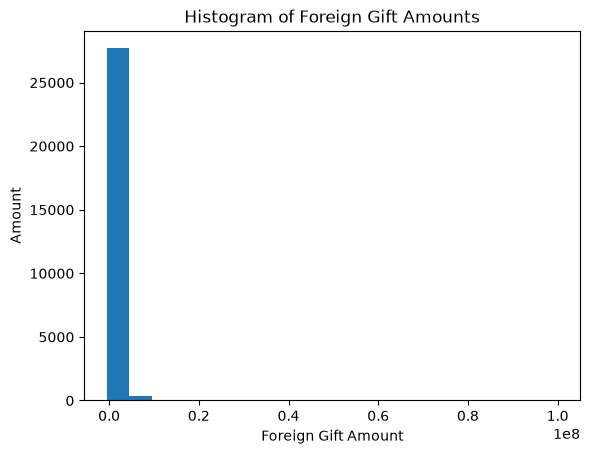

In [1]:
# Your Phase 1 solution to the problem goes here.

# All of my imports needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image

# Question 1 Equation Proofs are all in the image called Question 1 Equation Proofs.jpg
display(Image(filename='Question 1 Equation Proofs.jpg'))

# Saving the csv data to a pandas dataframe
df = pd.read_csv('data/ForeignGifts_edu.csv')
df.head()

# Copy of cleaned ForeignGifts from originial data set
df.to_csv('data/cleaned_ForeignGifts_edu.csv', index=False)

# Histogram of the number of gifts received by each country
df["Foreign Gift Amount"].hist(bins=20, grid=False)

plt.title("Histogram of Foreign Gift Amounts")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Amount")

In [2]:
# Describing the Foreign Gift Amount variable 
df["Foreign Gift Amount"].describe()

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64

Question: Describe your findings.

Answer: From the histogram and the describe() function, the Foreign Gift Amount shows that the inputs are near the origin.

Text(0, 0.5, 'Count')

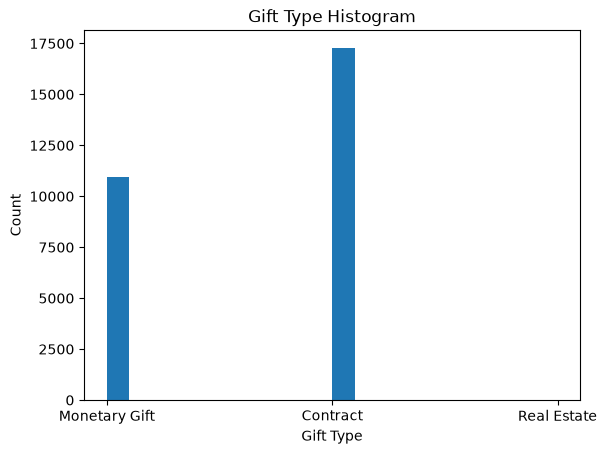

In [3]:
# Histogram of the number of gifts received by each gift type
df["Gift Type"].hist(bins=20, grid=False)

plt.title("Gift Type Histogram")
plt.xlabel("Gift Type")
plt.ylabel("Count")

In [4]:
# Proportion of monetary gifts
monetary = df[df['Gift Type'] == 'Monetary Gift']
print("Proportion of monetary gifts:", monetary.shape[0] / df.shape[0])

# Proportion of contract gifts
contract = df[df['Gift Type'] == 'Contract']
print("Proportion of contract gifts:", contract.shape[0] / df.shape[0])

# Proportion of real estate gifts
real_estate = df[df['Gift Type'] == 'Real Estate']
print("Proportion of contract gifts:", real_estate.shape[0] / df.shape[0])

Proportion of monetary gifts: 0.3875128450444704
Proportion of contract gifts: 0.6120973742957372
Proportion of contract gifts: 0.00038978065979235324


In [5]:
# Count of each gift type
df["Gift Type"].value_counts()

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64

Question: What proportion of the gifts are contracts, real estate, and monetary gifts?

Answer: The proportion of the gifts that are contracts are 38.75%. The proportion of the gifts that are real estate are 61.21% The proportion of the gifts that are monetary gifts are 0.039%.

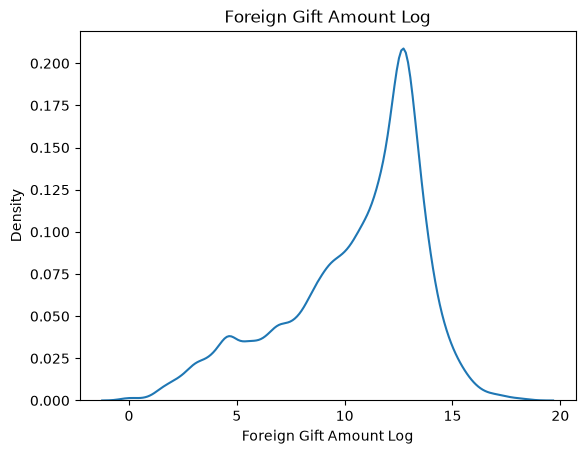

In [6]:
# Create a kernel density plot of the log of `Foreign Gift Amount`, 

# the Foreign Gift Amount (checks the foreign gift amount columns that are greater than 0 for log)
gift_data = df[df["Foreign Gift Amount"] > 0].copy()

# Creating log function
log_data = np.log(gift_data["Foreign Gift Amount"])

# Kernel density plot for the log of Foreign Gift Amount
sns.kdeplot(data = gift_data, x = log_data, label="Seaborn KDE")

plt.title("Foreign Gift Amount Log")

plt.xlabel("Foreign Gift Amount Log")
plt.ylabel("Density")

plt.show()

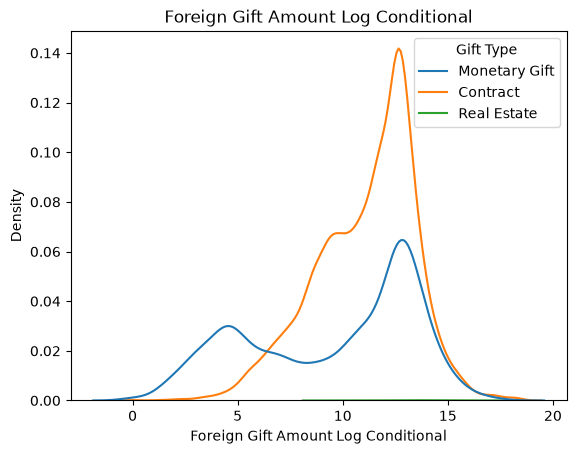

In [7]:
# The log foreign gift amount from data frame
df['Log_Foreign_Gift_Amount'] = np.log(gift_data["Foreign Gift Amount"])

# Kernel density plot of the log of `Foreign Gift Amount` conditional on gift type
sns.kdeplot(data = df, x = 'Log_Foreign_Gift_Amount', hue="Gift Type")

plt.title("Foreign Gift Amount Log Conditional")

plt.xlabel("Foreign Gift Amount Log Conditional")
plt.ylabel("Density")

plt.show()

Questions: Do you notice any patterns?

Answer: The patterns that I have noticed are Monetary Gift and Contrast both have two peaks (hills) and the second hill are near one another (and they're almost double the size).

In [25]:
# The top 15 countries with the most number of gifts
count_gift_foreign = df.groupby('Country of Giftor')['Foreign Gift Amount'].count().nlargest(15)

print("The top 15 countries with the most number of gifts:\n", count_gift_foreign)

# The top 15 countries with the most amount given
print("\nThe top 15 countries with the most amount given:")
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(15)

The top 15 countries with the most number of gifts:
 Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64

The top 15 countries with the most amount given:


Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

Questions: What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?

Answer: The top 15 countries in terms of the number of gifts are England, China, Canada, Japan, Switzerland, Saudi Arabia, France, Germany, Hong Kong, South Korea, Qater, The Netherlands, Korea, India, and Taiwan. The top 15 countries in terms of the amount given are Qatar, England, China, Saudi Arabia, Bermuda, Canada, Hong Kong, Japan, Switzerland, India, Germany, United Arab Emirates, France, Singapore, and Australia.

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [10]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]